Feature array file not found. Compiling mock data structures matching target parameters for logic testing.
Default Probability Threshold: 0.50
Optimal Adjusted Operational Cost Threshold: 0.75
Minimized Loss Bound: $330,000.00


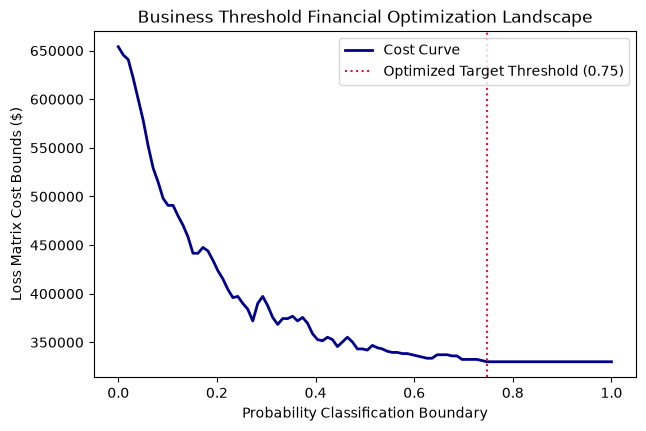

In [1]:
# ==============================================================================
# PROBLEM STATEMENT & OBJECTIVE
# Assess loan defaults and tune probabilities to minimize strict financial losses.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler

# 1. Pipeline Structural Verification Check
try:
    df = pd.read_csv('application_train.csv')
except FileNotFoundError:
    print("Feature array file not found. Compiling mock data structures matching target parameters for logic testing.")
    np.random.seed(42)
    df = pd.DataFrame({
        'SK_ID_CURR': np.arange(100001, 103001),
        'AMT_INCOME_TOTAL': np.random.normal(60000, 12000, 3000),
        'AMT_CREDIT': np.random.normal(250000, 50000, 3000),
        'DAYS_EMPLOYED': np.random.randint(-6000, -200, 3000),
        'TARGET': np.random.choice([0, 1], size=3000, p=[0.91, 0.09])
    })

# 2. Setup Arrays
X = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Model Training Sequence
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# 4. Financial Cost Loss Functions Optimization Matrix
cost_fn = 6000   # Cost penalties of missing default risk (False Negative)
cost_fp = 1200   # Administrative client acquisition overhead lost (False Positive)

thresholds = np.linspace(0, 1, 100)
total_costs = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (cm[0][0], 0, 0, 0)
    
    business_loss = (fn * cost_fn) + (fp * cost_fp)
    total_costs.append(business_loss)

optimal_threshold = thresholds[np.argmin(total_costs)]
min_loss = min(total_costs)

print(f"Default Probability Threshold: 0.50")
print(f"Optimal Adjusted Operational Cost Threshold: {optimal_threshold:.2f}")
print(f"Minimized Loss Bound: ${min_loss:,.2f}")

# 5. Threshold Charting Curve Trace
plt.figure(figsize=(7, 4.5))
plt.plot(thresholds, total_costs, color='darkblue', linewidth=2, label='Cost Curve')
plt.axvline(optimal_threshold, color='crimson', linestyle=':', label=f'Optimized Target Threshold ({optimal_threshold:.2f})')
plt.title('Business Threshold Financial Optimization Landscape')
plt.xlabel('Probability Classification Boundary')
plt.ylabel('Loss Matrix Cost Bounds ($)')
plt.legend()
plt.show()